# Проверка статистических гипотез: активность в Яндекс Книгах и A/B-тест интерфейса BitMotion Kit

- Автор: Каламагин Евгений Викторович
- Дата: 16.09.2026

Проект состоит из двух частей, в каждой из которых применяется статистическая проверка гипотез:

1. **Активность пользователей Яндекс Книг.** Сравнивается среднее время чтения и прослушивания книг у пользователей из Москвы и Санкт-Петербурга. Данные предварительно подготовлены в SQL.
2. **A/B-тест нового интерфейса интернет-магазина BitMotion Kit.** Проверяется корректность проведения теста и оценивается, привело ли изменение интерфейса к росту конверсии в покупку.

# Часть 1. Активность пользователей Яндекс Книг: Москва и Санкт-Петербург

В первой части проверяется гипотеза о том, что пользователи из Санкт-Петербурга проводят в приложении «Яндекс Книги» больше времени, чем пользователи из Москвы. Данные уже предобработаны в SQL и готовы к проверке гипотезы в Python.

## Цели и задачи

<font color='#777778'>Цель исследования — статистически проверить, действительно ли пользователи из Санкт-Петербурга в среднем тратят на чтение и прослушивание книг в приложении Яндекс Книги больше времени, чем пользователи из Москвы, и на основе результата сделать обоснованный вывод для бизнеса.

Задачи:

Загрузить данные пользователей из Москвы и Санкт-Петербурга с суммарным временем их активности.
Проверить данные на дубликаты по идентификатору пользователя и устранить их при необходимости.
Сравнить две группы по размеру выборок, описательным статистикам (среднее, медиана, стандартное отклонение) и форме распределения.
Сформулировать нулевую и альтернативную гипотезы и выбрать подходящий статистический критерий.
Провести одностороннюю проверку гипотезы с уровнем значимости α = 0.05 и получить p-value.
Интерпретировать результат и оформить выводы в виде аналитической записки, включая возможные причины наблюдаемой разницы.</font>

## Описание данных

Для анализа используется файл `yandex_knigi_data.csv`, содержащий данные пользователей из двух городов — Москвы и Санкт-Петербурга — с суммарным количеством часов их активности (чтение и прослушивание книг) в приложении Яндекс Книги. Всего в файле 8 784 записи: 6 234 из Москвы и 2 550 из Санкт-Петербурга.

Столбцы:

- `puid` — идентификатор пользователя;
- `city` — город пользователя (Москва / Санкт-Петербург);
- `hours` — суммарное время активности пользователя в приложении, часы.

Данные уже прошли предобработку на этапе SQL и готовы к статистическому анализу в Python.

## Структура части 1

1. Загрузка данных и первичный осмотр
2. Сравнение групп: размеры выборок, описательные статистики, распределения
3. Проверка дубликатов по идентификатору пользователя
4. Проверка гипотезы: формулировка H₀ и H₁, выбор типа t-теста, расчёт p-value
5. Аналитическая записка: интерпретация результата и возможные причины

---

## 1. Загрузка данных и первичный осмотр

Данные пользователей из Москвы и Санкт-Петербурга с суммой часов их активности (чтение и прослушивание) загружаются из файла `/datasets/yandex_knigi_data.csv`. После загрузки проверяются структура таблицы, типы данных и наличие пропусков.

### Импорт библиотек

Подключаются `pandas` и `numpy` для работы с данными, `matplotlib` для графиков, `scipy.stats` для t-теста, а также `statsmodels` — для расчёта размера выборки и z-теста для пропорций (используются во второй части проекта).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [5]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv', index_col=0)

df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


### Типы данных и пропуски

Проверяется, что все столбцы прочитаны в подходящих типах и нет пропусков. В таблице 8 784 записи, во всех трёх столбцах нет пустых значений: `puid` — целое число, `hours` — вещественное, `city` — строка.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


### Общая статистика по выборке

По всем пользователям сразу видно, что распределение времени активности сильно скошено вправо: среднее (≈ 11,1 ч) намного больше медианы (≈ 0,94 ч), а максимум достигает почти 979 ч.

In [7]:
df.describe(include='all')

,city,puid,hours
count,8784,8.784000e+03,8784.000000
unique,2,NaN,NaN
top,Москва,NaN,NaN
freq,6234,NaN,NaN
mean,NaN,1.029234e+13,11.087670
std,NaN,1.073532e+14,37.701350
min,NaN,9.668000e+03,0.000018
25%,NaN,3.239271e+08,0.066246
50%,NaN,8.828218e+08,0.942344
75%,NaN,1.516464e+09,6.065151


In [8]:
df.shape

(8784, 3)

## 2. Сравнение групп

### Размеры выборок и описательные статистики

Группы сравниваются по размеру и основным статистикам. Выборка из Москвы (6 234 пользователя) намного больше, чем из Санкт-Петербурга (2 550). Средние (10,88 и 11,59 ч) и медианы (0,92 и 0,98 ч) близки, а стандартные отклонения в разы превышают средние — то есть время активности у пользователей очень разное.

In [9]:
city_stats = df.groupby('city')['hours'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    max='max'
).round(2)

city_stats

,count,mean,median,std,min,q25,q75,max
city,,,,,,,,
Москва,6234,10.88,0.92,36.85,0.0,0.06,5.94,857.21
Санкт-Петербург,2550,11.59,0.98,39.70,0.0,0.08,6.51,978.76


### Выбросы

Выбросы оцениваются по правилу 1,5·IQR. В обоих городах за верхнюю границу выходит около 14–15% значений, при этом нет значений, превышающих число часов в году (8 784), — физически невозможных данных нет. Эти значения — реальная активность «тяжёлых» пользователей, поэтому из данных они не удаляются.

In [10]:
for city in df['city'].unique():
    city_data = df[df['city'] == city]['hours']
    q1 = city_data.quantile(0.25)
    q3 = city_data.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    n_outliers = ((city_data > upper_bound) | (city_data < lower_bound)).sum()
    print(f'{city}: верхняя граница IQR = {upper_bound:.2f}, '
          f'выбросов (по правилу 1.5*IQR) = {n_outliers} из {len(city_data)} '
          f'({n_outliers/len(city_data)*100:.1f}%)')
    print('Максимум часов:', df['hours'].max())
print('Строк с hours > 8784 (часов в году):', (df['hours'] > 8784).sum())

Москва: верхняя граница IQR = 14.76, выбросов (по правилу 1.5*IQR) = 900 из 6234 (14.4%)
Максимум часов: 978.7647747474748
Санкт-Петербург: верхняя граница IQR = 16.15, выбросов (по правилу 1.5*IQR) = 385 из 2550 (15.1%)
Максимум часов: 978.7647747474748
Строк с hours > 8784 (часов в году): 0


### Распределение времени активности

Гистограммы строятся сначала в исходной шкале, затем в логарифмической — `log(1 + hours)`. Логарифм нужен, чтобы при длинном правом хвосте можно было рассмотреть форму распределения основной массы пользователей.

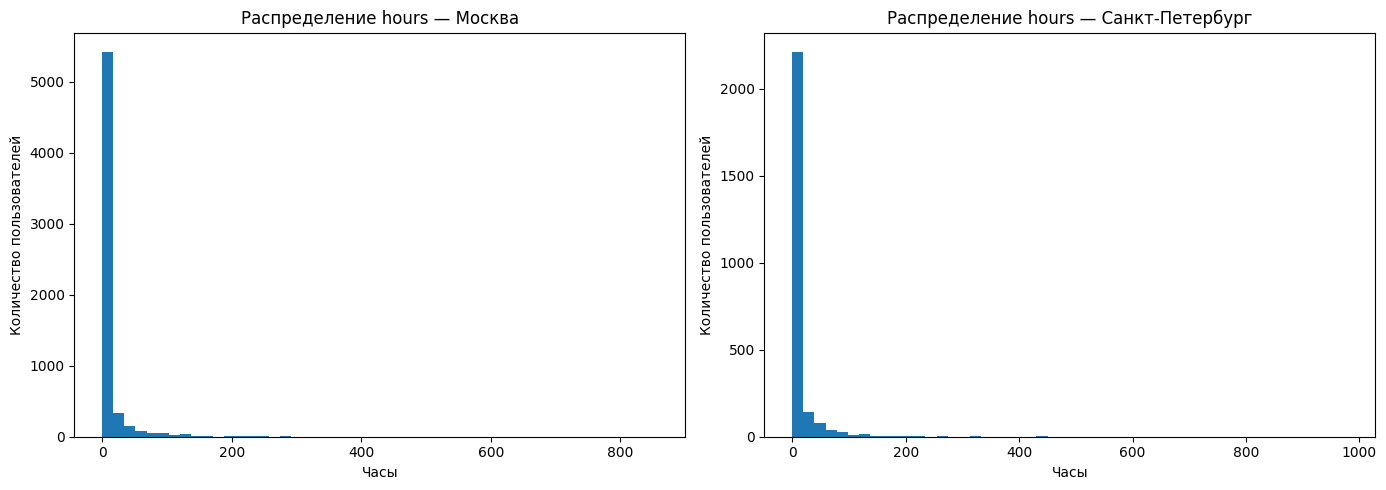

In [11]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city in zip(axes, df['city'].unique()):
    city_data = df[df['city'] == city]['hours']
    ax.hist(city_data, bins=50)
    ax.set_title(f'Распределение hours — {city}')
    ax.set_xlabel('Часы')
    ax.set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

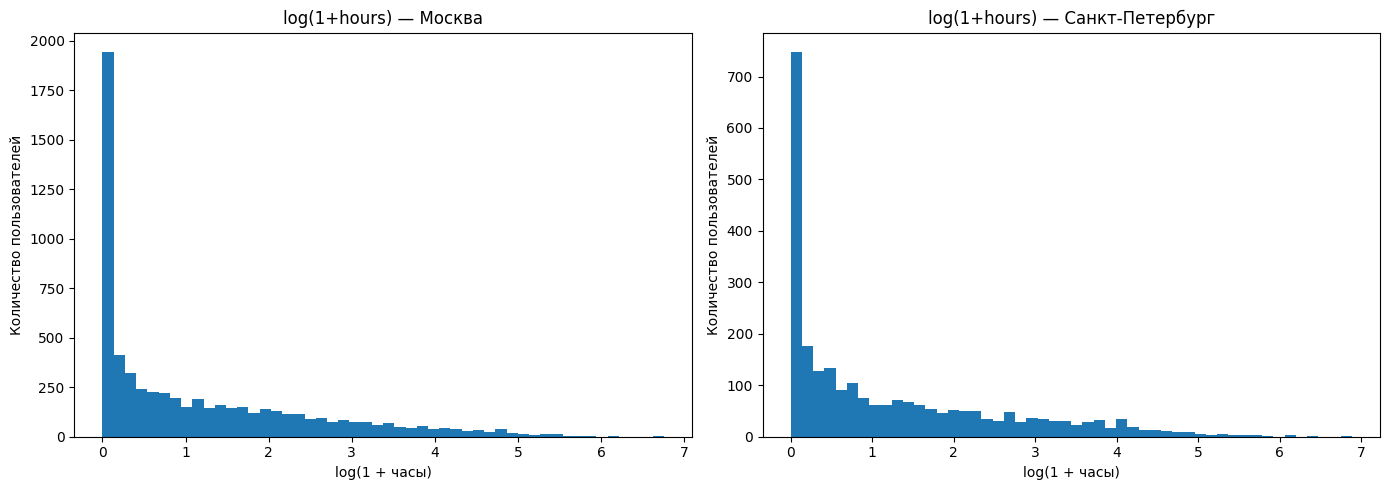

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, city in zip(axes, df['city'].unique()):
    city_data = df[df['city'] == city]['hours']
    ax.hist(np.log1p(city_data), bins=50)
    ax.set_title(f'log(1+hours) — {city}')
    ax.set_xlabel('log(1 + часы)')
    ax.set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

## 3. Проверка дубликатов

Данные проверяются на явные дубликаты (полностью совпадающие строки) и неявные — повторяющиеся идентификаторы пользователей `puid`. Явных дубликатов нет, но 244 значения `puid` встречаются повторно: как видно из примера ниже, часть пользователей попала в данные сразу по двум городам. Это важно учитывать при интерпретации результатов проверки гипотезы.

In [13]:
# Явные дубликаты (полностью одинаковые строки)
print('Явных дубликатов строк:', df.duplicated().sum())

# Неявные дубликаты по ключу пользователя (puid)
dup_puid = df['puid'].duplicated().sum()
print('Повторяющихся puid:', dup_puid)

if dup_puid > 0:
    display(df[df['puid'].duplicated(keep=False)].sort_values('puid'))

Явных дубликатов строк: 0
Повторяющихся puid: 244


,city,puid,hours
6247,Санкт-Петербург,2637041,3.883926
35,Москва,2637041,10.317371
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
...,...,...,...
8773,Санкт-Петербург,1130000020425037,2.386944
6202,Москва,1130000023864516,142.830085
8775,Санкт-Петербург,1130000023864516,14.384722
8779,Санкт-Петербург,1130000028554332,4.107774


## 4. Проверка гипотезы

Проверяется гипотеза о том, что пользователи из Санкт-Петербурга проводят в приложении в среднем больше времени за чтением и прослушиванием книг, чем пользователи из Москвы. Для этого используется односторонняя проверка гипотезы с двумя выборками:

- **Нулевая гипотеза H₀:** μСПб ≤ μМосква — средняя активность пользователей в Санкт-Петербурге не больше, чем в Москве.

- **Альтернативная гипотеза H₁:** μСПб > μМосква — средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

### Выбор критерия и расчёт p-value

Сравниваются две выборки разного размера с разным разбросом значений, поэтому применяется критерий Уэлча (`equal_var=False`) — он не требует равенства дисперсий. Параметр `alternative='greater'` задаёт одностороннюю проверку: H₁ утверждает, что среднее в Санкт-Петербурге больше, чем в Москве.

In [14]:
# Выделяем две выборки
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

# Односторонний t-тест
# H0: μСПб <= μМосква
# H1: μСПб > μМосква
results = stats.ttest_ind(
    spb,
    moscow,
    equal_var=False,
    alternative='greater'
)

print('p-value:', results.pvalue)

p-value: 0.21823507084569593


### Решение по результату теста

Полученное p-value сравнивается с уровнем значимости α = 0,05: если оно меньше, нулевая гипотеза отвергается.

In [15]:
alpha = 0.05

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу.')
    print('Есть статистически значимые основания считать, что пользователи из Санкт-Петербурга активнее пользователей из Москвы.')
else:
    print('Не отвергаем нулевую гипотезу.')
    print('Статистически значимых оснований считать, что пользователи из Санкт-Петербурга активнее пользователей из Москвы, недостаточно.')

Не отвергаем нулевую гипотезу.
Статистически значимых оснований считать, что пользователи из Санкт-Петербурга активнее пользователей из Москвы, недостаточно.


## 5. Аналитическая записка
Для проверки гипотезы был выбран односторонний t-тест для двух независимых выборок — критерий Уэлча (equal_var=False). Этот вариант теста используется без предположения о равенстве дисперсий в двух группах. Уровень статистической значимости принят равным α = 0.05.

Сформулированные гипотезы:

H₀: средняя активность пользователей из Санкт-Петербурга не превышает среднюю активность пользователей из Москвы: μСПб ≤ μМосква.
H₁: средняя активность пользователей из Санкт-Петербурга выше, чем в Москве: μСПб > μМосква.

В результате проведения одностороннего t-теста получено значение p-value = 0.2182.

Поскольку полученное значение p-value значительно больше выбранного уровня статистической значимости α = 0.05, нулевая гипотеза не отвергается. Таким образом, на основании имеющихся данных нет статистически значимых оснований утверждать, что пользователи из Санкт-Петербурга проводят в приложении больше времени за чтением и прослушиванием книг, чем пользователи из Москвы.

Одной из возможных причин такого результата может быть то, что фактическая средняя активность пользователей двух городов действительно близка и различие между ними недостаточно велико. Другой возможной причиной является высокая вариативность времени активности пользователей: в данных встречаются пользователи с очень разной продолжительностью использования приложения, что может затруднять выявление различий между группами.

# Часть 2. A/B-тест нового интерфейса интернет-магазина BitMotion Kit

Во второй части анализируются результаты A/B-теста интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У магазина есть своя целевая аудитория и хиты продаж: эспандер со счётчиком и напоминанием и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент, но сначала нужно решить одну проблему: по отзывам, интерфейс онлайн-магазина слишком сложен для пользователей. Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали её на части пользователей. Ожидается, что новая версия повысит долю пользователей, которые совершают покупку.

Цель части — оценить результаты A/B-теста. Для этого используются:

* данные о действиях пользователей и распределении их на группы;
* техническое задание.

В ходе анализа оцениваются корректность проведения теста и его результаты.

## 1. Цели исследования

1. Проверить корректность проведения A/B-теста `interface_eu_test`: распределение пользователей по группам, отсутствие пересечений и другие возможные нарушения условий эксперимента.

2. Сравнить конверсию пользователей в покупку в контрольной группе A и тестовой группе B в течение семи дней после регистрации.

3. Определить, является ли различие в конверсии между группами статистически значимым.

4. Проверить, достигает ли изменение конверсии целевого значения — увеличения как минимум на 3 процентных пункта.

## 2. Данные и их целостность

Загружаются две таблицы:

- `ab_test_participants` — участники тестов: идентификатор пользователя, группа (A или B), название теста и устройство;
- `ab_test_events` — события пользователей (регистрация, покупка и др.) с датой и временем.

Сначала проверяются состав и целостность таблицы участников.

In [16]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

### Таблица участников

Первичный осмотр таблицы `ab_test_participants`: структура, типы данных, пропуски и состав тестов.

In [17]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [18]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


В таблице 14 525 записей, пропусков нет. В ней два теста: `interface_eu_test` (10 850 записей) — изучаемый, и `recommender_system_test` (3 675 записей) — конкурирующий.

In [19]:
participants['ab_test'].value_counts()

,count
ab_test,
interface_eu_test,10850
recommender_system_test,3675


### Участники изучаемого теста

Выделяются участники `interface_eu_test`, а затем проверяются равномерность распределения по группам и дубликаты. Группы A и B почти равны по размеру (5 383 и 5 467 пользователей, доли 49,6% и 50,4%); в изучаемом тесте каждый пользователь встречается один раз и состоит только в одной группе.

In [20]:
test_users = participants[participants['ab_test'] == 'interface_eu_test'].copy()

test_users.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android


In [21]:
test_users['group'].value_counts(normalize=True)

,proportion
group,
B,0.503871
A,0.496129


In [22]:
test_users.groupby('group')['user_id'].nunique()

,user_id
group,
A,5383
B,5467


In [23]:
test_users['user_id'].duplicated().sum()

np.int64(0)

In [24]:
test_users.groupby('user_id')['group'].nunique().value_counts()

,count
group,
1,10850


In [25]:
participants['ab_test'].value_counts()

,count
ab_test,
interface_eu_test,10850
recommender_system_test,3675


## 3. Корректность проведения теста

### 3.1 Участники теста и соответствие условиям

По таблице `ab_test_participants` выделяются пользователи изучаемого теста, и проверяются:

- соответствие требованиям технического задания;
- равномерность распределения пользователей по группам теста;
- отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

### Пересечение с конкурирующим тестом

Проверяется, есть ли пользователи, участвующие одновременно в изучаемом и в конкурирующем тесте. Таких пользователей 887 — их придётся исключить, чтобы эффект другого теста не искажал результаты.

In [26]:
interface_users = set(
    participants.loc[
        participants['ab_test'] == 'interface_eu_test',
        'user_id'
    ]
)

other_test_users = set(
    participants.loc[
        participants['ab_test'] != 'interface_eu_test',
        'user_id'
    ]
)

intersection = interface_users & other_test_users

print('Участников interface_eu_test:', len(interface_users))
print('Участников других тестов:', len(other_test_users))
print('Пересечений:', len(intersection))

Участников interface_eu_test: 10850
Участников других тестов: 3675
Пересечений: 887


### Итог проверки участников

Сводка проверок по таблице участников: размер и доли групп, дубликаты и пересечения с другими тестами.

In [27]:
print('Количество участников:', test_users['user_id'].nunique())
print('\nРаспределение по группам:')
print(test_users.groupby('group')['user_id'].nunique())

print('\nДоли групп:')
print(test_users['group'].value_counts(normalize=True))

print('\nДубликаты user_id:', test_users['user_id'].duplicated().sum())

print('\nПересечения с другими тестами:', len(intersection))

Количество участников: 10850

Распределение по группам:
group
A    5383
B    5467
Name: user_id, dtype: int64

Доли групп:
group
B    0.503871
A    0.496129
Name: proportion, dtype: float64

Дубликаты user_id: 0

Пересечения с другими тестами: 887


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>

Верная проверка данных.


### 3.2 События участников теста

Таблица `ab_test_events` содержит данные о пользовательской активности. Для анализа оставляются только события пользователей, участвующих в изучаемом тесте.

Из анализа исключаются пользователи, участвующие в обоих тестах. После этого остаётся 9 963 участника.

In [28]:
# Пользователи, участвующие только в interface_eu_test
clean_users = test_users[
    ~test_users['user_id'].isin(intersection)
].copy()

print('Участников после исключения пересечений:', clean_users['user_id'].nunique())

Участников после исключения пересечений: 9963


In [29]:
test_events = events[
    events['user_id'].isin(clean_users['user_id'])
].copy()

test_events.head()

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


In [30]:
test_events.shape

(73815, 4)

### Горизонт анализа: первые 7 дней после регистрации

Для каждого пользователя рассчитывается лайфтайм — время, прошедшее с момента регистрации до события. В анализе остаются только события, выполненные в течение первых семи дней после регистрации.

Момент регистрации каждого пользователя определяется как время его первого события `registration`.

In [31]:
registrations = (
    test_events[test_events['event_name'] == 'registration']
    .groupby('user_id')['event_dt']
    .min()
    .reset_index()
    .rename(columns={'event_dt': 'registration_dt'})
)

registrations.head()

,user_id,registration_dt
0,0002CE61FF2C4011,2020-12-07 04:37:31
1,001E72F50D1C48FA,2020-12-17 15:44:05
2,002412F1EB3F6E38,2020-12-09 09:36:50
3,002540BE89C930FB,2020-12-08 18:06:07
4,0031F1B5E9FBF708,2020-12-14 00:47:10


In [32]:
test_events = test_events.merge(
    registrations,
    on='user_id',
    how='inner'
)

Лайфтайм считается в днях как разница между временем события и временем регистрации.

In [33]:
test_events['lifetime'] = (
    test_events['event_dt'] - test_events['registration_dt']
).dt.total_seconds() / (24 * 60 * 60)

In [34]:
test_events[['user_id', 'event_dt', 'registration_dt', 'lifetime']].head()

,user_id,event_dt,registration_dt,lifetime
0,5F506CEBEDC05D30,2020-12-06 14:10:01,2020-12-06 14:10:01,0.0
1,51278A006E918D97,2020-12-06 14:37:25,2020-12-06 14:37:25,0.0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,2020-12-06 17:20:22,0.0
3,275A8D6254ACF530,2020-12-06 19:36:54,2020-12-06 19:36:54,0.0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,2020-12-06 19:42:20,0.0


Оставляются события с лайфтаймом от 0 до 7 дней. После фильтрации остаётся 63 805 событий, максимальный лайфтайм — менее 7 дней.

In [35]:
test_events_7d = test_events[
    (test_events['lifetime'] >= 0) &
    (test_events['lifetime'] <= 7)
].copy()

In [36]:
test_events_7d['lifetime'].describe()

,lifetime
count,63805.000000
mean,1.366690
std,1.889863
min,0.000000
25%,0.000255
50%,0.032627
75%,2.304942
max,6.998727


### 3.3 Достаточность выборки

Проверяется, хватает ли пользователей в группах, чтобы статистически значимо обнаружить рост конверсии на 3 п.п. (с 30% до 33%). Параметры расчёта:

- базовый показатель конверсии — 30%;
- мощность теста — 80%;
- достоверность теста — 95% (α = 0,05).

In [37]:


baseline_conversion = 0.30
target_conversion = 0.33
alpha = 0.05
power = 0.80

effect_size = proportion_effectsize(
    baseline_conversion,
    target_conversion
)

analysis = NormalIndPower()

required_sample = analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1,
    alternative='two-sided'
)

print('Необходимое количество пользователей в одной группе:',
      np.ceil(required_sample))

Необходимое количество пользователей в одной группе: 3762.0


Необходимый размер группы сравнивается с фактическим. Для обнаружения роста конверсии с 30% до 33% нужно не менее 3 762 пользователей в каждой группе, а в группах A и B — 4 952 и 5 011 пользователей после исключения пересечений. Выборки достаточно.

In [38]:
clean_users.groupby('group')['user_id'].nunique()

,user_id
group,
A,4952
B,5011


In [39]:
required_n = np.ceil(required_sample)

group_sizes = clean_users.groupby('group')['user_id'].nunique()

print('Необходимо в каждой группе:', required_n)
print('\nФактически:')
print(group_sizes)

if (group_sizes >= required_n).all():
    print('\nВыборки достаточно для заданных параметров теста.')
else:
    print('\nВыборки недостаточно для заданных параметров теста.')

Необходимо в каждой группе: 3762.0

Фактически:
group
A    4952
B    5011
Name: user_id, dtype: int64

Выборки достаточно для заданных параметров теста.


### 3.4 Конверсия по группам

Для каждой группы считаются общее количество посетителей и количество посетителей, совершивших покупку в течение семи дней после регистрации. Конверсия — это доля покупателей среди всех посетителей группы.

Покупателями считаются пользователи, совершившие событие `purchase` в течение первых семи дней после регистрации.

In [40]:
purchases = test_events_7d[
    test_events_7d['event_name'] == 'purchase'
]

purchase_users = purchases['user_id'].unique()

In [41]:
clean_users['purchase'] = clean_users['user_id'].isin(
    purchase_users
)

In [42]:
conversion_table = (
    clean_users
    .groupby('group')
    .agg(
        visitors=('user_id', 'nunique'),
        purchasers=('purchase', 'sum')
    )
)

conversion_table['conversion'] = (
    conversion_table['purchasers'] /
    conversion_table['visitors']
)

conversion_table

,visitors,purchasers,conversion
group,,,
A,4952,1377,0.278069
B,5011,1480,0.295350


In [43]:
conversion_table['conversion_pct'] = (
    conversion_table['conversion'] * 100
).round(2)

conversion_table

,visitors,purchasers,conversion,conversion_pct
group,,,,
A,4952,1377,0.278069,27.81
B,5011,1480,0.295350,29.54


In [44]:
conversion_a = conversion_table.loc['A', 'conversion']
conversion_b = conversion_table.loc['B', 'conversion']

difference_pp = (conversion_b - conversion_a) * 100

print(f'Конверсия A: {conversion_a:.2%}')
print(f'Конверсия B: {conversion_b:.2%}')
print(f'Изменение: {difference_pp:.2f} п.п.')

Конверсия A: 27.81%
Конверсия B: 29.54%
Изменение: 1.73 п.п.


### 3.5 Предварительный вывод

Конверсия в тестовой группе B сравнивается с конверсией в контрольной группе A — так оценивается, как изменилась пользовательская активность.

In [45]:
if difference_pp > 0:
    print(
        f'В группе B конверсия выше группы A на '
        f'{difference_pp:.2f} п.п.'
    )
elif difference_pp < 0:
    print(
        f'В группе B конверсия ниже группы A на '
        f'{abs(difference_pp):.2f} п.п.'
    )
else:
    print('Разница в конверсии между группами отсутствует.')

В группе B конверсия выше группы A на 1.73 п.п.


## 4. Статистическая оценка результатов A/B-теста

### 4.1 Выбор критерия и формулировка гипотез

Для сравнения конверсий двух групп используется односторонний z-тест для двух пропорций с уровнем значимости α = 0,05. Проверка включает формулировку гипотез, расчёт статистики и p-value, сравнение p-value с α и вывод.

H₀ (нулевая гипотеза): конверсия в группе B не выше конверсии в группе A — p_B ≤ p_A. Различие, если оно наблюдается в выборке, объясняется случайностью.

H₁ (альтернативная гипотеза): конверсия в группе B выше конверсии в группе A — p_B > p_A.

### 4.2 Результат теста

Считаются z-статистика и p-value для разницы конверсий групп B и A.

In [46]:
count = [
    conversion_table.loc['B', 'purchasers'],
    conversion_table.loc['A', 'purchasers']
]

nobs = [
    conversion_table.loc['B', 'visitors'],
    conversion_table.loc['A', 'visitors']
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='larger'
)

print(f'Z-статистика: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

Z-статистика: 1.9070
p-value: 0.0283


### 4.3 Решение по гипотезе

p-value сравнивается с уровнем значимости α = 0,05.

In [47]:
alpha = 0.05

if p_value < alpha:
    print(
        'Отвергаем нулевую гипотезу: '
        'конверсия в группе B статистически значимо выше.'
    )
else:
    print(
        'Не отвергаем нулевую гипотезу: '
        'статистически значимого увеличения конверсии '
        'в группе B не обнаружено.'
    )

Отвергаем нулевую гипотезу: конверсия в группе B статистически значимо выше.


### 4.4 Достижение целевого эффекта

По техническому заданию конверсия должна вырасти не менее чем на 3 п.п. Фактическое изменение сравнивается с этим порогом — статистическая значимость и достижение бизнес-цели проверяются отдельно.

In [48]:
target_difference_pp = 3

print(f'Фактическое изменение: {difference_pp:.2f} п.п.')
print(f'Целевое изменение: {target_difference_pp:.2f} п.п.')

if difference_pp >= target_difference_pp:
    print('Целевое увеличение конверсии на 3 п.п. достигнуто.')
else:
    print('Целевое увеличение конверсии на 3 п.п. не достигнуто.')

Фактическое изменение: 1.73 п.п.
Целевое изменение: 3.00 п.п.
Целевое увеличение конверсии на 3 п.п. не достигнуто.


## 5. Выводы по A/B-тесту

Ниже подводятся итоги: что показали результаты теста и достигнут ли ожидаемый эффект в изменении конверсии.

Для оценки различий в конверсии между контрольной группой A и тестовой группой B был применён z-тест для сравнения двух пропорций. Уровень статистической значимости составил α = 0.05.

В контрольной группе A конверсия пользователей в покупку за первые 7 дней составила 27,81%, в тестовой группе B — 29,54%. Таким образом, наблюдаемое изменение конверсии составило +1,73 процентного пункта.

По результатам статистического теста получено:

Z-статистика = 1,9070;
p-value = 0,0283.

Так как p-value < 0,05, нулевая гипотеза отвергается. Следовательно, различие между группами является статистически значимым, и конверсия в тестовой группе B выше конверсии в контрольной группе A.

При этом изначально ожидаемый эффект эксперимента заключался в увеличении конверсии как минимум на 3 процентных пункта. Фактическое увеличение составило только 1,73 п.п., поэтому целевой эффект в +3 п.п. не достигнут.

Таким образом, изменение интерфейса привело к статистически значимому увеличению конверсии, однако величина полученного эффекта оказалась меньше установленного в техническом задании целевого значения. Поэтому результат теста подтверждает наличие положительного изменения конверсии, но не подтверждает достижение ожидаемого бизнес-эффекта в размере не менее 3 п.п.